In [2]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_context("talk")
sns.set_style("whitegrid")

# Only needed in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

Mounted at /content/drive


## **Paths & run-mode flags**

In [3]:
PROJECT_DIR    = "/content/drive/MyDrive/project"
DATA_DIR       = os.path.join(PROJECT_DIR, "dataset", "Yale-Brain-Mets-Longitudinal")
EXCEL_PATH     = os.path.join(PROJECT_DIR, "dataset/Yale-Brain-Mets-Longitudinal_ClinicalData_20250605.xlsx")

PREPROCESSED_DIR = os.path.join(PROJECT_DIR, "dataset/preprocessed")   # full 3D volumes after pipeline
SLICES_DIR       = os.path.join(PROJECT_DIR, "dataset/full_slices")         # 2D .npy cache for training
MANIFEST_DIR     = os.path.join(PROJECT_DIR, "manifests")
FIGURES_DIR      = os.path.join(PROJECT_DIR, "figures")

for d in [PREPROCESSED_DIR, SLICES_DIR, MANIFEST_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

SUBSET_MODE       = False   # False for full dataset run
SUBSET_N_PATIENTS = 5
TARGET_SPACING_MM = (1.0, 1.0, 1.0)
SLICE_SIZE_PX     = 192    # output 2D crop size around tumor
RANDOM_SEED       = 42

np.random.seed(RANDOM_SEED)

## **Build a hardened manifest**

- Generates **all valid pairs** within each patient's trajectory (not just consecutive),
  which multiplies training data and exposes the model to a wider Δt distribution.
- Applies a `min_delta_days` floor and a `max_delta_days` ceiling to exclude same-week
  scans and pathological jumps.
- Verifies every file path exists on disk; drops broken pairs and logs how many.
- Stores a unique `pair_id` so you can trace any sample back to its source.

In [4]:
def build_manifest(
    metadata_excel: str,
    data_dir: str,
    cache_path: str = None,
    force_rebuild: bool = False,
    min_delta_days: int = 7,
    max_delta_days: int = 365,
    all_pairs: bool = True,
    sequence_class: str = "POST",
) -> pd.DataFrame:
    # ---- load from cache if it exists ----
    if cache_path and os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached manifest from {cache_path}")
        cached = pd.read_csv(cache_path, parse_dates=["baseline_date", "followup_date"])
        print(f"  -> {len(cached):,} pairs, "
              f"{cached['patient_id'].nunique():,} patients")
        return cached

    # ---- otherwise, build from scratch ----
    df = pd.read_excel(metadata_excel, sheet_name="image_acquisition_parameters")
    df["study_datetime"] = pd.to_datetime(df["study_datetime"], format="%Y-%m-%d_%H-%M-%S")

    df = df[df["sequence_class"] == sequence_class].copy()
    df = df.sort_values(["patient_id", "study_datetime"]).reset_index(drop=True)

    rows = []
    for pid, group in df.groupby("patient_id"):
        if len(group) < 2:
            continue
        group = group.reset_index(drop=True)

        if all_pairs:
            idx_pairs = [(i, j) for i in range(len(group)) for j in range(i + 1, len(group))]
        else:
            idx_pairs = [(i, i + 1) for i in range(len(group) - 1)]

        for i, j in idx_pairs:
            s_t, s_n = group.iloc[i], group.iloc[j]
            dt = (s_n["study_datetime"] - s_t["study_datetime"]).days
            if not (min_delta_days <= dt <= max_delta_days):
                continue
            date_t = s_t["study_datetime"].strftime("%Y-%m-%d")
            date_n = s_n["study_datetime"].strftime("%Y-%m-%d")
            p_xt   = os.path.join(data_dir, pid, date_t, s_t["file_name"])
            p_next = os.path.join(data_dir, pid, date_n, s_n["file_name"])
            rows.append({
                "patient_id":      pid,
                "pair_id":         f"{pid}_{i}_{j}",
                "scan_idx_t":      i,
                "scan_idx_next":   j,
                "path_xt":         p_xt,
                "path_next":       p_next,
                "exists_xt":       os.path.exists(p_xt),
                "exists_next":     os.path.exists(p_next),
                "delta_t_days":    dt,
                "baseline_date":   s_t["study_datetime"],
                "followup_date":   s_n["study_datetime"],
                "slice_thickness": s_t.get("slice_thickness (mm)", np.nan),
            })

    manifest = pd.DataFrame(rows)

    print(f"Total candidate pairs:           {len(manifest):,}")
    print(f"Unique patients with ≥2 scans:   {manifest['patient_id'].nunique():,}")
    missing = manifest[(~manifest.exists_xt) | (~manifest.exists_next)]
    print(f"Pairs dropped for missing files: {len(missing):,}")

    manifest = manifest[manifest.exists_xt & manifest.exists_next].reset_index(drop=True)

    # ---- save cache ----
    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        manifest.to_csv(cache_path, index=False)
        print(f"Saved manifest to {cache_path}")

    return manifest


# ---- usage ----
MANIFEST_CACHE = os.path.join(MANIFEST_DIR, "manifest_raw_pairs_all.csv")

manifest = build_manifest(
    EXCEL_PATH,
    DATA_DIR,
    cache_path=MANIFEST_CACHE,
    force_rebuild=True,    # flip to True to regenerate
    all_pairs=True,
)

manifest.head()

Total candidate pairs:           23,643
Unique patients with ≥2 scans:   1,134
Pairs dropped for missing files: 5,183
Saved manifest to /content/drive/MyDrive/project/manifests/manifest_raw_pairs_all.csv


,patient_id,pair_id,scan_idx_t,scan_idx_next,path_xt,path_next,exists_xt,exists_next,delta_t_days,baseline_date,followup_date,slice_thickness
0,YG_01M98EKKAR50,YG_01M98EKKAR50_0_1,0,1,/content/drive/MyDrive/project/dataset/Yale-Br...,/content/drive/MyDrive/project/dataset/Yale-Br...,True,True,14,2016-11-13 10:16:23,2016-11-27 10:38:46,5.0
1,YG_021XTGZ9QY91,YG_021XTGZ9QY91_0_1,0,1,/content/drive/MyDrive/project/dataset/Yale-Br...,/content/drive/MyDrive/project/dataset/Yale-Br...,True,True,8,2016-01-30 19:05:08,2016-02-08 11:19:51,5.0
2,YG_021XTGZ9QY91,YG_021XTGZ9QY91_0_2,0,2,/content/drive/MyDrive/project/dataset/Yale-Br...,/content/drive/MyDrive/project/dataset/Yale-Br...,True,True,50,2016-01-30 19:05:08,2016-03-21 16:57:50,5.0
3,YG_021XTGZ9QY91,YG_021XTGZ9QY91_0_3,0,3,/content/drive/MyDrive/project/dataset/Yale-Br...,/content/drive/MyDrive/project/dataset/Yale-Br...,True,True,171,2016-01-30 19:05:08,2016-07-20 14:47:44,5.0
4,YG_021XTGZ9QY91,YG_021XTGZ9QY91_0_4,0,4,/content/drive/MyDrive/project/dataset/Yale-Br...,/content/drive/MyDrive/project/dataset/Yale-Br...,True,True,204,2016-01-30 19:05:08,2016-08-22 13:34:51,5.0


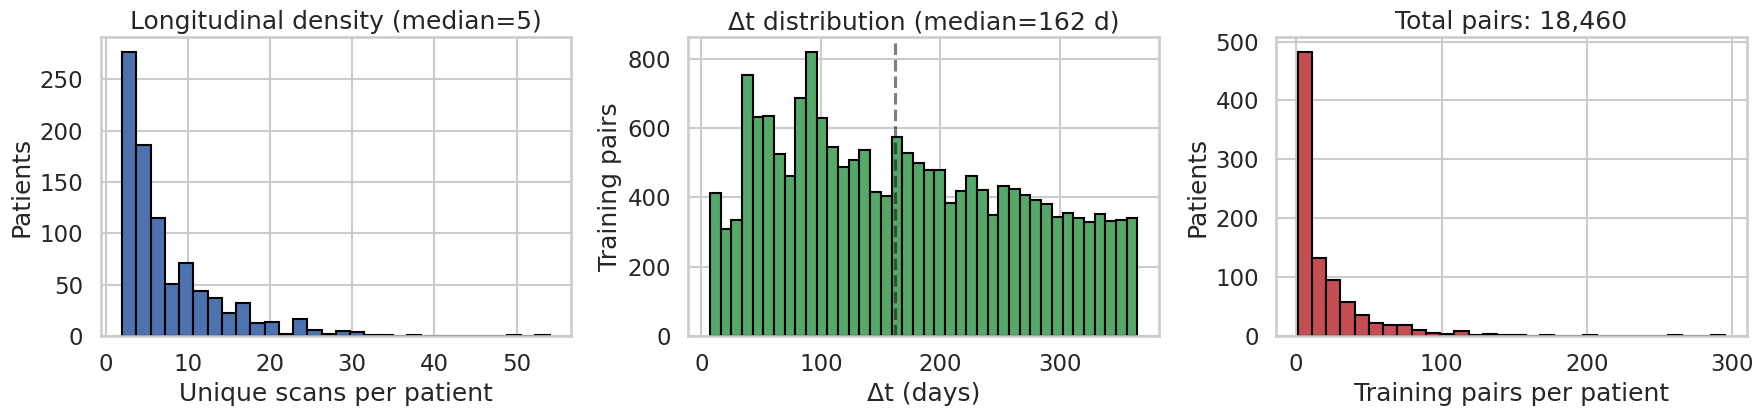

In [ ]:
cscans_per_patient = (
    pd.concat([manifest["patient_id"], manifest.rename(columns={"patient_id": "pid"})["pid"]])
    .drop_duplicates()
    .value_counts()
)

scans_per_patient = manifest.groupby("patient_id")["scan_idx_next"].max().add(1)
pairs_per_patient = manifest.groupby("patient_id").size()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].hist(scans_per_patient, bins=30, color="#4C72B0", edgecolor="black")
axes[0].set(xlabel="Unique scans per patient", ylabel="Patients",
            title=f"Longitudinal density (median={scans_per_patient.median():.0f})")

axes[1].hist(manifest["delta_t_days"], bins=40, color="#55A868", edgecolor="black")
axes[1].set(xlabel="Δt (days)", ylabel="Training pairs",
            title=f"Δt distribution (median={manifest.delta_t_days.median():.0f} d)")
axes[1].axvline(manifest.delta_t_days.median(), color="k", linestyle="--", alpha=0.5)

axes[2].hist(pairs_per_patient, bins=30, color="#C44E52", edgecolor="black")
axes[2].set(xlabel="Training pairs per patient", ylabel="Patients",
            title=f"Total pairs: {len(manifest):,}")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_manifest_stats.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df = pd.read_excel(EXCEL_PATH, sheet_name="image_acquisition_parameters")
df["study_datetime"] = pd.to_datetime(df["study_datetime"], format="%Y-%m-%d_%H-%M-%S")
df = df[df["sequence_class"] == "POST"].copy()

df["date_str"] = df["study_datetime"].dt.strftime("%Y-%m-%d")
df["expected_path"] = df.apply(
    lambda r: os.path.join(DATA_DIR, r["patient_id"], r["date_str"], r["file_name"]),
    axis=1,
)
df["exists"] = df["expected_path"].apply(os.path.exists)

missing_scans = df[~df["exists"]].copy()
print(f"Total POST scans in Excel:       {len(df):,}")
print(f"Unique missing scans:            {len(missing_scans):,}")
print(f"Patients with any missing scan:  {missing_scans['patient_id'].nunique()}")

print("\nTop 10 patients by missing-scan count:")
print(missing_scans.groupby("patient_id").size().sort_values(ascending=False).head(10))

# By year — era effect?
missing_scans["year"] = missing_scans["study_datetime"].dt.year
print("\nMissing scans by year:")
print(missing_scans["year"].value_counts().sort_index())

if len(missing_scans) > 0:
    pid = missing_scans.groupby("patient_id").size().sort_values(ascending=False).index[0]
    print(f"\n=== {pid}: Excel-expected vs on-disk ===")
    for p in missing_scans[missing_scans.patient_id == pid]["expected_path"].tolist()[:5]:
        print(f"  expected: {p}")
    on_disk = sorted((Path(DATA_DIR) / pid).rglob("*.nii.gz"))
    print(f"  on disk ({len(on_disk)} files):")
    for p in on_disk[:10]:
        print(f"    {p}")

Total POST scans in Excel:       8,996
Unique missing scans:            1,920
Patients with any missing scan:  296

Top 10 patients by missing-scan count:
patient_id
YG_Y57DU8SLLWAH    43
YG_XAF7IPT3UZ7C    33
YG_ZY8FHTNT2A8S    32
YG_ZZECURU4NBRG    32
YG_T11KX6PO59ZR    29
YG_Y7C93QKLIZXJ    28
YG_VSG5BBZNWI0Z    28
YG_VDIND5UAJG8W    26
YG_W5YYQ5QICNMX    26
YG_TGGSFW380L05    25
dtype: int64

Missing scans by year:
year
2011     41
2012     72
2013    176
2014    182
2015    200
2016    176
2017    194
2018    182
2019    191
2020    172
2021    172
2022    156
2023      6
Name: count, dtype: int64

=== YG_Y57DU8SLLWAH: Excel-expected vs on-disk ===
  expected: /content/drive/MyDrive/project/dataset/Yale-Brain-Mets-Longitudinal/YG_Y57DU8SLLWAH/2013-06-19/YG_Y57DU8SLLWAH_2013-06-19_09-33-22_POST.nii.gz
  expected: /content/drive/MyDrive/project/dataset/Yale-Brain-Mets-Longitudinal/YG_Y57DU8SLLWAH/2013-07-13/YG_Y57DU8SLLWAH_2013-07-13_07-58-07_POST.nii.gz
  expected: /content/drive/M

In [ ]:
from pathlib import Path

excel_df = pd.read_excel(EXCEL_PATH, sheet_name="image_acquisition_parameters")
excel_df = excel_df[excel_df["sequence_class"] == "POST"]
expected_per_patient = excel_df.groupby("patient_id").size().to_dict()

patient_status = []
for pid in expected_per_patient:
    pdir = Path(DATA_DIR) / pid
    expected = expected_per_patient[pid]
    if not pdir.exists():
        patient_status.append((pid, "folder_missing", 0, expected))
        continue
    n = len(list(pdir.rglob("*.nii.gz")))
    if n == 0:
        status = "folder_empty"
    elif n < expected:
        status = "partial"
    else:
        status = "complete"
    patient_status.append((pid, status, n, expected))

ps = pd.DataFrame(
    patient_status,
    columns=["patient_id", "status", "n_files", "n_expected"],
)
print(ps["status"].value_counts())
print("\nPartial patients (sample):")
print(ps[ps.status == "partial"].head(10))

status
complete          1081
folder_missing     280
partial              1
Name: count, dtype: int64

Partial patients (sample):
          patient_id   status  n_files  n_expected
832  YG_LULOUEAAF28Y  partial        4           5


## **Patient-level train/val/test split**
* splitting by `patient_id`not by pair.

In [7]:
from sklearn.model_selection import train_test_split

patients = sorted(manifest["patient_id"].unique())
train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=RANDOM_SEED)
val_p,   test_p = train_test_split(temp_p,   test_size=0.50, random_state=RANDOM_SEED)

split_map = {p: "train" for p in train_p} | {p: "val" for p in val_p} | {p: "test" for p in test_p}
manifest["split"] = manifest["patient_id"].map(split_map)
manifest.to_csv(os.path.join(MANIFEST_DIR, "manifest_split.csv"), index=False)

split_summary = manifest.groupby("split").agg(
    pairs=("pair_id", "count"),
    patients=("patient_id", "nunique"),
    mean_delta=("delta_t_days", "mean"),
)
print(split_summary)

       pairs  patients  mean_delta
split                             
test    3378       136  175.029899
train  12354       632  168.533754
val     2728       135  167.971041


No patient leakage across splits.


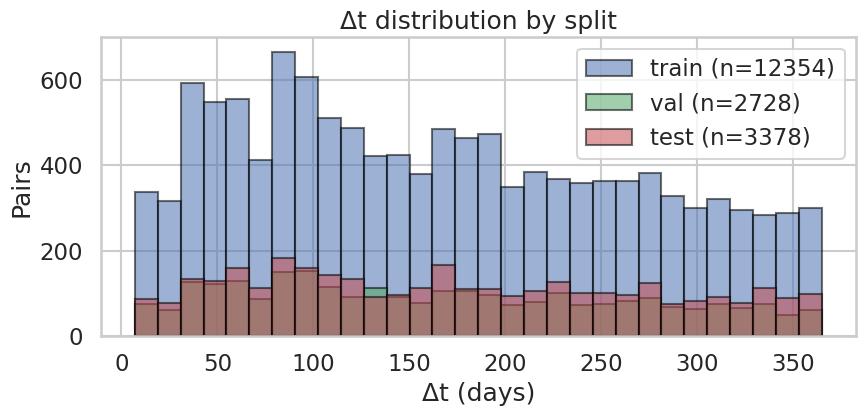

In [ ]:
# verify that there is no data leakage after dataset split

assert set(train_p).isdisjoint(val_p)
assert set(train_p).isdisjoint(test_p)
assert set(val_p).isdisjoint(test_p)
print("No patient leakage across splits.")

fig, ax = plt.subplots(figsize=(9, 4.5))
for s, c in zip(["train", "val", "test"], ["#4C72B0", "#55A868", "#C44E52"]):
    subset = manifest[manifest.split == s]["delta_t_days"]
    ax.hist(subset, bins=30, alpha=0.55, label=f"{s} (n={len(subset)})", color=c, edgecolor="black")
ax.set(xlabel="Δt (days)", ylabel="Pairs", title="Δt distribution by split")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_split_delta_t.png"), dpi=150, bbox_inches="tight")
plt.show()

## **Preprocessing primitives**

In [9]:
!pip install -q antspyx antspynet nibabel SimpleITK tqdm scikit-image seaborn scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.6/147.6 kB 9.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 50.7 MB/s eta 0:00:00


In [10]:
import ants
import antspynet


def step_n4_bias(img: "ants.ANTsImage") -> "ants.ANTsImage":
    """Remove low-frequency intensity bias field. Run before skull stripping."""
    return ants.n4_bias_field_correction(img)


def step_skull_strip(img: "ants.ANTsImage", threshold: float = 0.5):
    """Return (skull-stripped volume, brain mask) using a pretrained T1 network."""
    prob = antspynet.brain_extraction(img, modality="t1")
    mask = ants.threshold_image(prob, threshold, 1.0)
    return img * mask, mask


def step_register_rigid(moving: "ants.ANTsImage", fixed: "ants.ANTsImage"):
    """Rigidly align `moving` onto `fixed` (baseline). Returns (warped, forward_transform)."""
    reg = ants.registration(fixed=fixed, moving=moving, type_of_transform="Rigid")
    return reg["warpedmovout"], reg["fwdtransforms"]


def step_resample(img: "ants.ANTsImage", spacing=TARGET_SPACING_MM) -> "ants.ANTsImage":
    """Resample to isotropic voxel spacing using linear interpolation."""
    return ants.resample_image(img, spacing, use_voxels=False, interp_type=1)


def step_znorm(img: "ants.ANTsImage") -> "ants.ANTsImage":
    """Z-score normalization restricted to the brain (arr > 0). Background stays 0."""
    arr = img.numpy()
    mask = arr > 0
    if mask.sum() > 0:
        mu, sd = arr[mask].mean(), arr[mask].std()
        arr = np.where(mask, (arr - mu) / (sd + 1e-8), 0.0)
    return img.new_image_like(arr)


def preprocess_volume(
    in_path: str,
    out_path: str,
    baseline_img: "ants.ANTsImage" = None,
    return_steps: bool = False,
):
    """Full per-volume pipeline. If `baseline_img` is None, this volume IS the baseline."""
    raw = ants.image_read(in_path)
    n4  = step_n4_bias(raw)
    brain, mask = step_skull_strip(n4)
    if baseline_img is not None:
        registered, _ = step_register_rigid(brain, baseline_img)
    else:
        registered = brain
    resampled = step_resample(registered)
    normed    = step_znorm(resampled)
    ants.image_write(normed, out_path)
    if return_steps:
        return normed, {"raw": raw, "n4": n4, "brain": brain, "registered": registered,
                        "resampled": resampled, "normed": normed, "mask": mask}
    return normed

def preprocess_volume_fast(in_path, out_path, baseline_img=None, return_steps=False,
                           skip_skull_strip=True):
    """Faster pipeline: skip skull strip if Yale ships pre-stripped volumes."""
    raw = ants.image_read(in_path)
    n4  = step_n4_bias(raw)

    if skip_skull_strip:
        brain = n4
        mask = None
    else:
        brain, mask = step_skull_strip(n4)

    if baseline_img is not None:
        registered, _ = step_register_rigid(brain, baseline_img)
    else:
        registered = brain

    resampled = step_resample(registered)
    normed    = step_znorm(resampled)
    ants.image_write(normed, out_path)

    if return_steps:
        return normed, {
            "raw": raw, "n4": n4, "brain": brain,
            "registered": registered, "resampled": resampled,
            "normed": normed, "mask": mask,
        }
    return normed

Demo patient: YG_01M98EKKAR50 | /content/drive/MyDrive/project/dataset/Yale-Brain-Mets-Longitudinal/YG_01M98EKKAR50/2016-11-13/YG_01M98EKKAR50_2016-11-13_10-16-23_POST.nii.gz


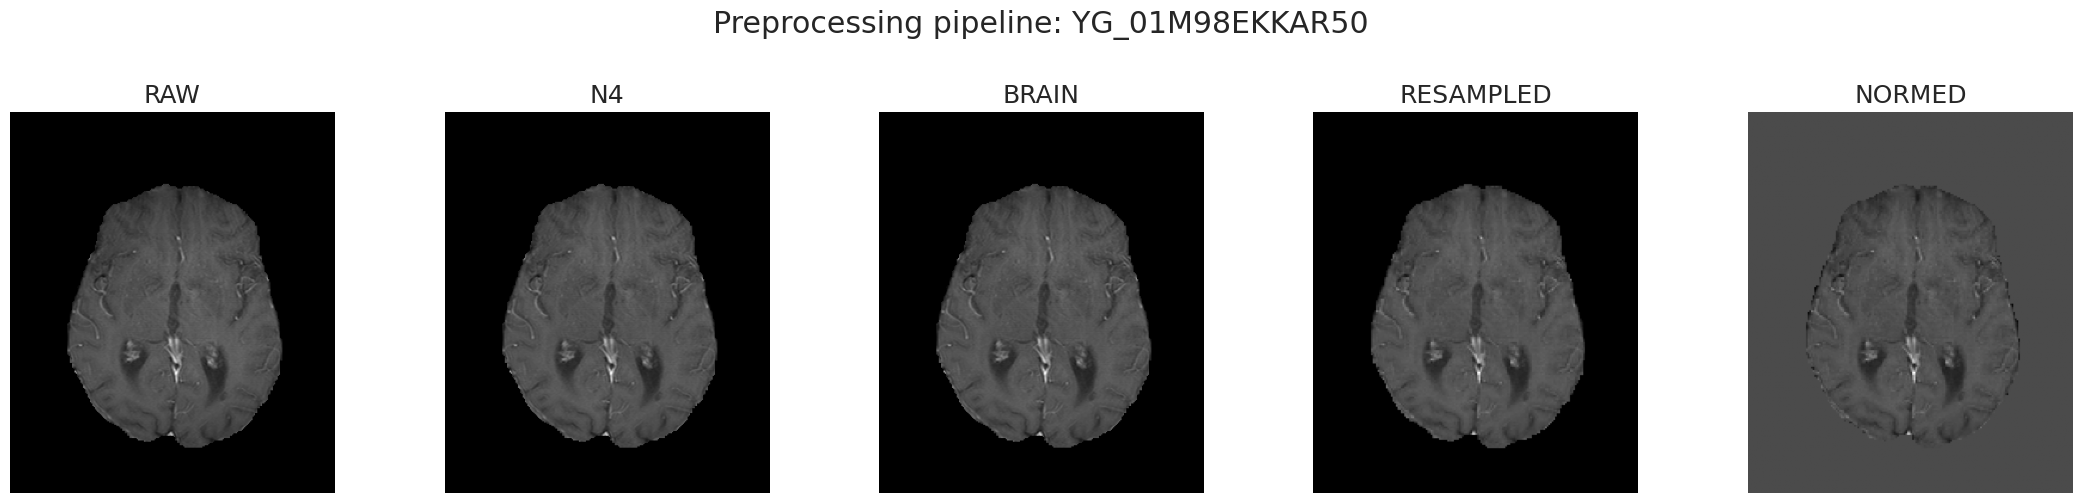

In [ ]:
def middle_slice(vol):
    arr = vol.numpy() if hasattr(vol, "numpy") else vol
    return arr[:, :, arr.shape[2] // 2].T


sample_row = manifest[manifest.split == "train"].iloc[0]
print(f"Demo patient: {sample_row['patient_id']} | {sample_row['path_xt']}")

_, steps = preprocess_volume_fast(
    in_path=sample_row["path_xt"],
    out_path=os.path.join(PREPROCESSED_DIR, f"_demo_{sample_row['patient_id']}.nii.gz"),
    baseline_img=None,
    return_steps=True,
)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, name in zip(axes, ["raw", "n4", "brain", "resampled", "normed"]):
    ax.imshow(middle_slice(steps[name]), cmap="gray", origin="lower")
    ax.set_title(name.upper())
    ax.axis("off")
plt.suptitle(f"Preprocessing pipeline: {sample_row['patient_id']}", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_preprocessing_steps.png"), dpi=150, bbox_inches="tight")
plt.show()

## **Preprocessing for All Dataset**

In [ ]:
import shutil, time, json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

LOCAL_DATA = "/content/local_data/Yale-Brain-Mets-Longitudinal"
LOCAL_OUT  = "/content/local_preprocessed"
Path(LOCAL_DATA).mkdir(parents=True, exist_ok=True)
Path(LOCAL_OUT).mkdir(parents=True, exist_ok=True)

OLD_DATA_DIR = DATA_DIR
N_PATIENTS = 200
SEED       = 0

def select_patients(manifest, n_patients, seed=0):
    rng = np.random.default_rng(seed)
    patients_per_split = (manifest.drop_duplicates("patient_id")
                                  .groupby("split")["patient_id"]
                                  .apply(lambda s: sorted(s.tolist()))
                                  .to_dict())
    permuted = {}
    for split in sorted(patients_per_split):                # fixed split order
        permuted[split] = list(rng.permutation(patients_per_split[split]))
    total  = sum(len(v) for v in permuted.values())
    picked = []
    for split, ids in permuted.items():
        k = max(1, min(round(n_patients * len(ids) / total), len(ids)))
        picked += ids[:k]                                    # prefix → naturally nested
    return sorted(picked)

if N_PATIENTS is None:
    patients_to_process = sorted(manifest["patient_id"].unique())
else:
    patients_to_process = select_patients(manifest, N_PATIENTS, seed=SEED)

print(f"Processing {len(patients_to_process)} patients "
      f"(splits: {manifest[manifest.patient_id.isin(patients_to_process)]['split'].value_counts().to_dict()})")

patient_list_path = os.path.join(MANIFEST_DIR, f"patients_n{N_PATIENTS}.json")
with open(patient_list_path, "w") as f:
    json.dump({"n_patients": N_PATIENTS, "seed": SEED,
               "patient_ids": patients_to_process}, f, indent=2)
print(f"Saved patient list → {patient_list_path}")

prev = sorted(Path(MANIFEST_DIR).glob("patients_n*.json"))
prev = [p for p in prev if p.name != f"patients_n{N_PATIENTS}.json"]
for p in prev:
    with open(p) as f:
        prev_ids = json.load(f)["patient_ids"]
    if len(prev_ids) <= len(patients_to_process):
        missing = set(prev_ids) - set(patients_to_process)
        assert not missing, (
            f"NESTING BROKEN: {len(missing)} patients in {p.name} are "
            f"NOT in current N={N_PATIENTS} selection: {sorted(missing)[:5]}..."
        )
        print(f"  OK: {p.name} ({len(prev_ids)} patients) ⊆ current selection")

def stage_one(pid):
    src, dst = Path(OLD_DATA_DIR) / pid, Path(LOCAL_DATA) / pid
    if not src.exists(): return 0
    n = 0
    for post in src.rglob("*POST.nii.gz"):
        rel = post.relative_to(src); out = dst / rel
        if out.exists(): continue
        out.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(post, out); n += 1
    return n

t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    counts = list(ex.map(stage_one, patients_to_process))
print(f"Staged {sum(counts)} files from {len(patients_to_process)} patients in {time.time()-t0:.0f}s")

DATA_DIR = LOCAL_DATA
PREPROCESSED_DIR = LOCAL_OUT

Processing 200 patients (splits: {'train': 2746, 'val': 685, 'test': 612})
Saved patient list → /content/drive/MyDrive/project/manifests/patients_n200.json
  OK: patients_n100.json (100 patients) ⊆ current selection
  OK: patients_n150.json (150 patients) ⊆ current selection
Staged 1456 files from 200 patients in 91s


In [12]:
manifest["path_xt"]   = manifest["path_xt"]  .str.replace(OLD_DATA_DIR, LOCAL_DATA, regex=False)
manifest["path_next"] = manifest["path_next"].str.replace(OLD_DATA_DIR, LOCAL_DATA, regex=False)
manifest["exists_xt"]   = manifest["path_xt"]  .apply(os.path.exists)
manifest["exists_next"] = manifest["path_next"].apply(os.path.exists)

sub_manifest = manifest[
    manifest.patient_id.isin(patients_to_process) &     # restrict to current N=100 selection
    manifest.exists_xt &
    manifest.exists_next
].reset_index(drop=True)

print(f"Local pairs available: {len(sub_manifest):,} "
      f"across {sub_manifest['patient_id'].nunique()} patients")

Local pairs available: 4,043 across 200 patients


In [13]:
SKIP_N4 = True  # Yale volumes are pre-corrected; verify on one if paranoid

def preprocess_volume_fast(in_path, out_path, baseline_raw_path=None,
                           return_steps=False, skip_skull_strip=True, skip_n4=True):
    """If baseline_raw_path is given, rigid-register against the RAW baseline file
    (same intensity scale as the moving image — fixes the silent-fail bug)."""
    raw = ants.image_read(in_path)
    n4  = raw if skip_n4 else step_n4_bias(raw)
    brain = n4 if skip_skull_strip else step_skull_strip(n4)[0]

    if baseline_raw_path is not None:
        baseline_raw = ants.image_read(baseline_raw_path)
        registered, _ = step_register_rigid(brain, baseline_raw)
        # sanity check — reject empty registrations loudly
        if float(registered.numpy().std()) < 1e-3:
            raise RuntimeError(f"Registration failed (empty output) for {in_path}")
    else:
        registered = brain

    resampled = step_resample(registered)
    normed    = step_znorm(resampled)
    ants.image_write(normed, out_path)
    if return_steps:
        return normed, {"raw": raw, "n4": n4, "brain": brain,
                        "registered": registered, "resampled": resampled,
                        "normed": normed, "mask": None}
    return normed

In [14]:
def unique_scan_paths(manifest_df: pd.DataFrame):
    """Return a DataFrame of every unique scan that appears in any pair."""
    a = manifest_df[["patient_id", "path_xt"]].rename(columns={"path_xt": "path"})
    b = manifest_df[["patient_id", "path_next"]].rename(columns={"path_next": "path"})
    return pd.concat([a, b]).drop_duplicates().reset_index(drop=True)


def preprocessed_path_for(raw_path: str) -> str:
    stem = Path(raw_path).stem.replace(".nii", "")
    patient = Path(raw_path).parent.parent.name
    return os.path.join(PREPROCESSED_DIR, patient, f"{stem}.nii.gz")


def run_preprocessing(manifest_df, subset_n=None):
    patients = sorted(manifest_df["patient_id"].unique())
    if subset_n is not None:
        patients = patients[:subset_n]
    sub = manifest_df[manifest_df.patient_id.isin(patients)].copy()

    scans = unique_scan_paths(sub)

    baseline_scan = (
        sub.sort_values("baseline_date")
           .groupby("patient_id")
           .agg(baseline_path=("path_xt", "first"))
           .reset_index()
    )
    baseline_map = dict(zip(baseline_scan.patient_id, baseline_scan.baseline_path))

    failed = []

    # Baselines — process standalone (no registration target)
    for pid, bpath in tqdm(baseline_map.items(), desc="Baselines"):
        out = preprocessed_path_for(bpath)
        os.makedirs(os.path.dirname(out), exist_ok=True)
        if os.path.exists(out):
            continue
        try:
            preprocess_volume_fast(bpath, out, baseline_raw_path=None,
                                   skip_n4=True, skip_skull_strip=True)
        except Exception as e:
            print(f"[skip baseline] {pid}: {e}")
            failed.append((pid, bpath, str(e)))

    # Follow-ups — register against the RAW baseline path
    followups = scans[~scans["path"].isin(baseline_map.values())]
    for _, row in tqdm(followups.iterrows(), total=len(followups), desc="Follow-ups"):
        out = preprocessed_path_for(row["path"])
        os.makedirs(os.path.dirname(out), exist_ok=True)
        if os.path.exists(out):
            continue
        pid = row["patient_id"]
        if pid not in baseline_map:
            continue
        try:
            preprocess_volume_fast(row["path"], out,
                                   baseline_raw_path=baseline_map[pid],
                                   skip_n4=True, skip_skull_strip=True)
        except Exception as e:
            print(f"[skip followup] {row['path']}: {e}")
            failed.append((pid, row["path"], str(e)))
            if os.path.exists(out): os.remove(out)  # don't poison cache

    print(f"\nDone. {len(failed)} volumes skipped.")
    if failed:
        pd.DataFrame(failed, columns=["patient_id", "path", "error"]).to_csv(
            os.path.join(MANIFEST_DIR, "preprocessing_failures.csv"), index=False
        )
    return baseline_map

In [15]:
for pid in patients_to_process:
    !rsync -a /content/drive/MyDrive/project/dataset/preprocessed/{pid}/ /content/local_preprocessed/{pid}/

In [ ]:
!rsync -a /content/drive/MyDrive/project/dataset/preprocessed/ /content/local_preprocessed/

# Verify
local_n = sum(1 for _ in Path('/content/local_preprocessed').rglob('*.nii.gz'))
drive_n = sum(1 for _ in Path('/content/drive/MyDrive/project/dataset/preprocessed').rglob('*.nii.gz'))
print(f"Local: {local_n}  |  Drive: {drive_n}")

Local: 6793  |  Drive: 6793


In [16]:
baseline_map = run_preprocessing(sub_manifest, subset_n=None)

Baselines:   0%|          | 0/200 [00:00<?, ?it/s]

Follow-ups:   0%|          | 0/1236 [00:00<?, ?it/s]


Done. 0 volumes skipped.


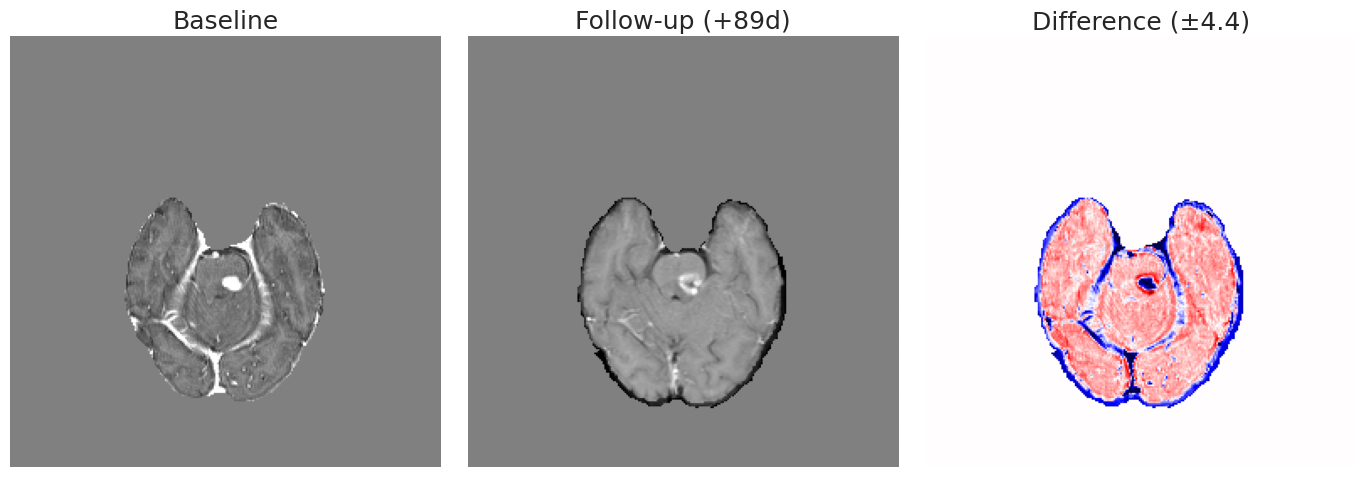

In [ ]:
demo_pid = list(baseline_map.keys())[6]
row = manifest[manifest.patient_id == demo_pid].iloc[0]
b = ants.image_read(preprocessed_path_for(row["path_xt"])).numpy()
f = ants.image_read(preprocessed_path_for(row["path_next"])).numpy()
z = b.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(b[:, :, z].T, cmap="gray", origin="lower", vmin=-3, vmax=3)
axes[0].set_title("Baseline"); axes[0].axis("off")
axes[1].imshow(f[:, :, z].T, cmap="gray", origin="lower", vmin=-3, vmax=3)
axes[1].set_title(f"Follow-up (+{row['delta_t_days']}d)"); axes[1].axis("off")

vrange = np.percentile(np.abs((f - b)[(b != 0) & (f != 0)]), 99)
axes[2].imshow((f - b)[:, :, z].T, cmap="seismic", origin="lower",
               vmin=-vrange, vmax=+vrange)
axes[2].set_title(f"Difference (±{vrange:.1f})"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_registration_check.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
!rsync -a /content/local_preprocessed/ /content/drive/MyDrive/project/dataset/preprocessed/


In [ ]:
outliers = diffs[diffs["mean_diff"].abs() > 0.2].merge(
    sub_manifest[["pair_id", "patient_id", "delta_t_days", "split"]],
    on="pair_id"
)
print(outliers.groupby("split").size())
print(outliers.head(10))

NameError: name 'diffs' is not defined

## **Tumor ROI detection**

In [17]:
from scipy.ndimage import label as cc_label

def brain_center_bbox(pre_arr: np.ndarray, crop_size: int = SLICE_SIZE_PX):
    """Fixed crop_size^3 bounding box centered on the brain's centroid.
    Clamps to volume edges so the returned box is always crop_size on each axis."""
    brain = pre_arr != 0
    if brain.sum() == 0:
        # fallback: geometric center of the whole volume
        center = np.array(pre_arr.shape) // 2
    else:
        coords = np.array(np.nonzero(brain))
        center = coords.mean(axis=1).astype(int)
    half = crop_size // 2
    mins = np.maximum(center - half, 0)
    maxs = mins + crop_size
    # back off if we ran off the edge
    maxs = np.minimum(maxs, np.array(pre_arr.shape))
    mins = maxs - crop_size
    return tuple(mins.tolist()), tuple(maxs.tolist())


def get_or_predict_tumor_mask(preproc_path: str, raw_path: str):
    """First-pass strategy: return a brain-center field-of-view box as the ROI.
    Source tag is 'brain_center' so downstream code / figures can distinguish
    this from a real tumor segmentation (planned upgrade: BraTS multi-modal)."""
    pre_arr = ants.image_read(preproc_path).numpy()
    mins, maxs = brain_center_bbox(pre_arr, crop_size=SLICE_SIZE_PX)
    mask = np.zeros_like(pre_arr, dtype=np.uint8)
    mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]] = 1
    return mask, "brain_center"


def tumor_bbox_from_mask(mask_arr: np.ndarray, margin: int = 0):
    """3D bounding box (inclusive min, exclusive max) around nonzero voxels.
    margin=0 by default because brain_center_bbox already returns the exact box."""
    coords = np.array(np.nonzero(mask_arr))
    if coords.size == 0:
        return None
    mins = np.maximum(coords.min(axis=1) - margin, 0)
    maxs = np.minimum(coords.max(axis=1) + margin + 1, mask_arr.shape)
    return tuple(mins.tolist()), tuple(maxs.tolist())

In [ ]:
demo_row = manifest[manifest.patient_id == demo_pid].iloc[0]
demo_pre = preprocessed_path_for(demo_row["path_xt"])
mask_arr, mask_src = get_or_predict_tumor_mask(demo_pre, demo_row["path_xt"])
bbox = tumor_bbox_from_mask(mask_arr)
print(f"ROI source: {mask_src} | bbox: {bbox}")

pre_arr = ants.image_read(demo_pre).numpy()
z = (bbox[0][2] + bbox[1][2]) // 2 if bbox else pre_arr.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# left: brain with ROI overlay
axes[0].imshow(pre_arr[:, :, z].T, cmap="gray", origin="lower")
axes[0].imshow(
    np.ma.masked_where(mask_arr[:, :, z].T == 0, mask_arr[:, :, z].T),
    cmap="autumn", alpha=0.25, origin="lower",
)
axes[0].set_title(f"ROI overlay ({mask_src})"); axes[0].axis("off")

# right: brain with bounding box
if bbox:
    (y0, x0, _), (y1, x1, _) = bbox
    axes[1].imshow(pre_arr[:, :, z].T, cmap="gray", origin="lower")
    rect = plt.Rectangle((y0, x0), y1 - y0, x1 - x0,
                         linewidth=2, edgecolor="red", facecolor="none")
    axes[1].add_patch(rect)
    axes[1].set_title(f"Crop bounding box ({SLICE_SIZE_PX}×{SLICE_SIZE_PX})")
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_tumor_roi.png"), dpi=150, bbox_inches="tight")
plt.show()

## **Cell 8 — Extract 2D slice pairs and cache them**

In [ ]:
PREPROCESSED_DIR = "/content/local_preprocessed"

sample_raw = sub_manifest["path_xt"].iloc[0]
sample_pre = preprocessed_path_for(sample_raw)
print(f"PREPROCESSED_DIR: {PREPROCESSED_DIR}")
print(f"Example preprocessed path: {sample_pre}")
print(f"File exists? {os.path.exists(sample_pre)}")

# count how many patients' preprocessed volumes actually live there
n_patient_dirs = len(list(Path(PREPROCESSED_DIR).iterdir())) if Path(PREPROCESSED_DIR).exists() else 0
print(f"Patient subdirs under PREPROCESSED_DIR: {n_patient_dirs}")

PREPROCESSED_DIR: /content/local_preprocessed
Example preprocessed path: /content/local_preprocessed/YG_05MQ79QMQ47J/YG_05MQ79QMQ47J_2016-12-15_13-49-34_POST.nii.gz
File exists? True
Patient subdirs under PREPROCESSED_DIR: 200


In [19]:
import glob
def center_crop_2d(arr2d: np.ndarray, cy: int, cx: int, size: int = SLICE_SIZE_PX):
    """Crop a 2D array to `size×size` centered on (cy, cx), padding with 0 if needed."""
    h, w = arr2d.shape
    half = size // 2
    out = np.zeros((size, size), dtype=arr2d.dtype)
    y0, y1 = cy - half, cy + half
    x0, x1 = cx - half, cx + half
    src_y0, src_x0 = max(y0, 0), max(x0, 0)
    src_y1, src_x1 = min(y1, h), min(x1, w)
    dst_y0, dst_x0 = src_y0 - y0, src_x0 - x0
    dst_y1, dst_x1 = dst_y0 + (src_y1 - src_y0), dst_x0 + (src_x1 - src_x0)
    out[dst_y0:dst_y1, dst_x0:dst_x1] = arr2d[src_y0:src_y1, src_x0:src_x1]
    return out


def extract_slice_pairs_multi(row, slice_size: int = SLICE_SIZE_PX,
                              min_brain_fraction: float = 0.2,
                              stride: int = 1):
    """Return list of (slice_t, slice_next, z_idx, meta) for every axial slice
    with enough brain content. Registration already ensures z-correspondence
    between baseline and follow-up."""
    p_xt   = preprocessed_path_for(row["path_xt"])
    p_next = preprocessed_path_for(row["path_next"])
    if not (os.path.exists(p_xt) and os.path.exists(p_next)):
        return []

    vol_t = ants.image_read(p_xt).numpy()
    vol_n = ants.image_read(p_next).numpy()

    if vol_t.shape != vol_n.shape:
        return []  # registration shape mismatch — skip

    # brain centroid for consistent (cy, cx) across all z in this pair
    mins, maxs = brain_center_bbox(vol_t, crop_size=slice_size)
    cy = (mins[0] + maxs[0]) // 2
    cx = (mins[1] + maxs[1]) // 2

    z_total = vol_t.shape[2]
    out = []
    for z in range(0, z_total, stride):
        slab_t = vol_t[:, :, z]
        slab_n = vol_n[:, :, z]
        brain_frac = float((slab_t != 0).mean())
        if brain_frac < min_brain_fraction:
            continue
        s_t = center_crop_2d(slab_t, cy, cx, slice_size)
        s_n = center_crop_2d(slab_n, cy, cx, slice_size)
        out.append((s_t, s_n, z, {"brain_frac": brain_frac}))
    return out


import glob
from pathlib import Path

def cache_all_slices_multi(manifest_df: pd.DataFrame, stride: int = 1, save_every: int = 25):
    out_rows = []
    out_csv  = os.path.join(MANIFEST_DIR, "slices_manifest_full_200.csv")
    print(f"Target CSV: {out_csv}")
    print(f"Pairs to process: {len(manifest_df)}  |  incremental save every {save_every}\n")

    def _flush(tag=""):
        if not out_rows:
            return
        tmp = out_csv + ".tmp"
        pd.DataFrame(out_rows).to_csv(tmp, index=False)
        os.replace(tmp, out_csv)                       # atomic — never leaves a half-written file
        size_kb = os.path.getsize(out_csv) / 1024
        tqdm.write(f"  [save{tag}] {len(out_rows):,} rows, {size_kb:.1f} KB → {out_csv}")

    try:
        for i, (_, row) in enumerate(tqdm(manifest_df.iterrows(),
                                          total=len(manifest_df), desc="Slicing pairs"), start=1):
            out_dir = os.path.join(SLICES_DIR, row["patient_id"])
            os.makedirs(out_dir, exist_ok=True)

            existing_slices = glob.glob(os.path.join(out_dir, f"{row['pair_id']}_z*_t.npy"))

            if existing_slices:
                # Re-index existing slices into the manifest (do NOT re-slice)
                for p_t in sorted(existing_slices):
                    slice_id = Path(p_t).stem[:-2]                      # strip "_t"
                    p_n = os.path.join(out_dir, f"{slice_id}_next.npy")
                    if not os.path.exists(p_n):
                        continue
                    try:
                        z = int(slice_id.rsplit("_z", 1)[1])
                    except (IndexError, ValueError):
                        z = -1
                    out_rows.append({
                        "patient_id":   row["patient_id"],
                        "pair_id":      row["pair_id"],
                        "slice_id":     slice_id,
                        "z_idx":        z,
                        "split":        row["split"],
                        "slice_t":      p_t,
                        "slice_next":   p_n,
                        "delta_t_days": row["delta_t_days"],
                        "brain_frac":   np.nan,
                    })
                # Incremental save then go to next row (skip slicing)
                if i % save_every == 0:
                    _flush(f" {i}/{len(manifest_df)}")
                continue

            # Fresh slicing path
            slices = extract_slice_pairs_multi(row, stride=stride)
            if not slices:
                if i % save_every == 0:
                    _flush(f" {i}/{len(manifest_df)}")
                continue

            for s_t, s_n, z, meta in slices:
                slice_id = f"{row['pair_id']}_z{z:03d}"
                p_t = os.path.join(out_dir, f"{slice_id}_t.npy")
                p_n = os.path.join(out_dir, f"{slice_id}_next.npy")
                np.save(p_t, s_t.astype(np.float32))
                np.save(p_n, s_n.astype(np.float32))
                out_rows.append({
                    "patient_id":   row["patient_id"],
                    "pair_id":      row["pair_id"],
                    "slice_id":     slice_id,
                    "z_idx":        z,
                    "split":        row["split"],
                    "slice_t":      p_t,
                    "slice_next":   p_n,
                    "delta_t_days": row["delta_t_days"],
                    "brain_frac":   meta["brain_frac"],
                })

            if i % save_every == 0:
                _flush(f" {i}/{len(manifest_df)}")

    except KeyboardInterrupt:
        print("\nInterrupted — flushing partial CSV...")
    except Exception as e:
        print(f"\nError: {e!r} — flushing partial CSV before re-raising...")
        _flush(" on-error")
        raise
    finally:
        _flush(" final")
        print(f"\nFinal CSV: {out_csv}")
        print(f"Exists:    {os.path.exists(out_csv)}")
        if os.path.exists(out_csv):
            print(f"Size:      {os.path.getsize(out_csv)/1024:.1f} KB")
            print(f"Rows:      {len(out_rows):,}")

    return pd.DataFrame(out_rows)


# --- Usage unchanged ---
def _pair_preprocessed_exists(row):
    return (os.path.exists(preprocessed_path_for(row["path_xt"])) and
            os.path.exists(preprocessed_path_for(row["path_next"])))

sub_manifest = manifest[manifest.patient_id.isin(baseline_map.keys())].copy()
before = len(sub_manifest)
sub_manifest = sub_manifest[sub_manifest.apply(_pair_preprocessed_exists, axis=1)].reset_index(drop=True)
print(f"Pairs with both preprocessed volumes: {len(sub_manifest)} / {before}")

slices_manifest = cache_all_slices_multi(sub_manifest, stride=3, save_every=25)
print(f"\nCached {len(slices_manifest):,} slice pairs "
      f"from {sub_manifest['pair_id'].nunique()} volume pairs "
      f"(~{len(slices_manifest) / max(sub_manifest['pair_id'].nunique(), 1):.0f} slices/pair)")
slices_manifest.head()

Pairs with both preprocessed volumes: 4043 / 4043
Target CSV: /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
Pairs to process: 4043  |  incremental save every 25



Slicing pairs:   0%|          | 0/4043 [00:00<?, ?it/s]

  [save 25/4043] 563 rows, 151.0 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 50/4043] 1,120 rows, 300.0 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 75/4043] 1,645 rows, 441.6 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 100/4043] 2,074 rows, 556.9 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 125/4043] 2,604 rows, 698.3 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 150/4043] 3,196 rows, 856.7 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 175/4043] 3,715 rows, 995.6 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 200/4043] 4,179 rows, 1119.7 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [save 225/4043] 4,880 rows, 1307.3 KB → /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
  [s

,patient_id,pair_id,slice_id,z_idx,split,slice_t,slice_next,delta_t_days,brain_frac
0,YG_05MQ79QMQ47J,YG_05MQ79QMQ47J_0_1,YG_05MQ79QMQ47J_0_1_z054,54,train,/content/drive/MyDrive/project/dataset/full_sl...,/content/drive/MyDrive/project/dataset/full_sl...,18,NaN
1,YG_05MQ79QMQ47J,YG_05MQ79QMQ47J_0_1,YG_05MQ79QMQ47J_0_1_z057,57,train,/content/drive/MyDrive/project/dataset/full_sl...,/content/drive/MyDrive/project/dataset/full_sl...,18,NaN
2,YG_05MQ79QMQ47J,YG_05MQ79QMQ47J_0_1,YG_05MQ79QMQ47J_0_1_z060,60,train,/content/drive/MyDrive/project/dataset/full_sl...,/content/drive/MyDrive/project/dataset/full_sl...,18,NaN
3,YG_05MQ79QMQ47J,YG_05MQ79QMQ47J_0_1,YG_05MQ79QMQ47J_0_1_z063,63,train,/content/drive/MyDrive/project/dataset/full_sl...,/content/drive/MyDrive/project/dataset/full_sl...,18,NaN
4,YG_05MQ79QMQ47J,YG_05MQ79QMQ47J_0_1,YG_05MQ79QMQ47J_0_1_z066,66,train,/content/drive/MyDrive/project/dataset/full_sl...,/content/drive/MyDrive/project/dataset/full_sl...,18,NaN


In [20]:
import pandas as pd
import os

CSV_PATH = "/content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv"

df = pd.read_csv(CSV_PATH)

print(f"File:            {CSV_PATH}")
print(f"Size on disk:    {os.path.getsize(CSV_PATH)/1024:.1f} KB")
print(f"Total rows:      {len(df):,}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"Unique pairs:    {df['pair_id'].nunique()}")

# Per-split breakdown (if the split column exists)
if "split" in df.columns:
    print("\nBy split:")
    print(df.groupby("split").agg(
        slices=("slice_id", "count"),
        pairs=("pair_id", "nunique"),
        patients=("patient_id", "nunique"),
    ))

# Per-patient slice counts (top 10 + bottom 10)
pp = df.groupby("patient_id").size().sort_values(ascending=False)
print(f"\nSlices per patient — mean={pp.mean():.0f}, median={pp.median():.0f}, "
      f"min={pp.min()}, max={pp.max()}")
print("\nTop 5 patients by slice count:")
print(pp.head())
print("\nBottom 5 patients by slice count:")
print(pp.tail())

File:            /content/drive/MyDrive/project/manifests/slices_manifest_full_200.csv
Size on disk:    28988.6 KB
Total rows:      107,536
Unique patients: 200
Unique pairs:    4043

By split:
       slices  pairs  patients
split                         
test    17227    612        30
train   73643   2746       140
val     16666    685        30

Slices per patient — mean=538, median=190, min=9, max=8731

Top 5 patients by slice count:
patient_id
YG_NRSFSRTTONBY    8731
YG_IU1NODAR8ZCZ    4512
YG_R3QCBUTVEO98    3915
YG_QLW4GDHFNOUK    3830
YG_DQZYSBZQZ4IR    2802
dtype: int64

Bottom 5 patients by slice count:
patient_id
YG_LN74VA6O770X    16
YG_AY6L5LJYGH60    15
YG_H388CV6U8NV0    14
YG_EXCLBGF55XLD    13
YG_R0H0MTV7NEZ2     9
dtype: int64


In [ ]:
def plot_triplet_grid(df: pd.DataFrame, n: int = 6, save_to: str = None):
    sample = df.sample(min(n, len(df)), random_state=RANDOM_SEED)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[None, :]
    for ax_row, (_, r) in zip(axes, sample.iterrows()):
        xt = np.load(r["slice_t"])
        xn = np.load(r["slice_next"])
        ax_row[0].imshow(xt, cmap="gray"); ax_row[0].set_title(f"baseline — {r['patient_id']}")
        ax_row[1].imshow(xn, cmap="gray"); ax_row[1].set_title(f"+{r['delta_t_days']} d")
        ax_row[2].imshow(xn - xt, cmap="seismic", vmin=-2, vmax=2); ax_row[2].set_title("Δ")
        for a in ax_row: a.axis("off")
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150, bbox_inches="tight")
    plt.show()

plot_triplet_grid(slices_manifest, n=6,
                  save_to=os.path.join(FIGURES_DIR, "fig_sample_triplets.png"))